# Skin-temperature dynamics — end-to-end tutorial

A narrated walkthrough of the pipeline from
[Burks et al., *npj Digital Medicine* (2026)](https://doi.org/10.1038/s41746-026-02633-2),
run entirely on **synthetic** data (no private wearable data required).

We will:
1. generate a synthetic Oura-like cohort,
2. segment sleep and select isolated **activity perturbations**,
3. quantify the directional MET → ΔT coupling (transfer entropy),
4. fit the **linear** (Eqs. 1–3) and **mechanistic** (Eqs. 4–6) models,
5. compare condition **cohorts** by their dynamical biomarkers.

> The synthetic data is built from the paper's *forward* model with planted
> condition effects, so recovering those effects validates the estimators — it
> is not independent evidence about human physiology.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt

from skin_temp_perfusion.config import PipelineConfig
from skin_temp_perfusion.synthetic import generate_dataset
from skin_temp_perfusion import pipeline as pl, plotting as viz
from skin_temp_perfusion.io import load_participant, load_demographics
from skin_temp_perfusion.sleep import extract_sleep_windows
from skin_temp_perfusion.perturbations import extract_trajectories, temp_columns
from skin_temp_perfusion.mechanistic import fit_trajectory, reconstruct

viz.apply_style()
config = PipelineConfig(min_trajectories_per_participant=20, min_cohort_size=10)
DATA = "synthetic_demo"  # written next to this notebook

## 1. Generate a synthetic cohort
Each participant gets latent (k₁, a, b, k₂) shifted by planted age, sex, and condition effects.

In [2]:
demo = generate_dataset(400, DATA, n_nights=14, seed=42)
print(f"{len(demo)} participants | {demo['cd_none'].mean():.0%} condition-free controls")
demo.head()

400 participants | 36% condition-free controls


,age,sex,bmi,cd_hypertension,cd_diabetes,cd_coronary,cd_afib,cd_myocardial,cd_congestive,cd_stroke,cd_sleepapnea,cd_none
PID,,,,,,,,,,,,
P0000,33.147307,male,16.000000,0,0,0,0,0,0,0,1,0
P0001,51.944283,female,23.859614,1,0,0,0,0,0,0,0,0
P0002,59.460236,male,30.829719,0,0,0,0,0,0,0,0,1
P0003,31.717522,female,36.586138,1,0,0,0,0,0,0,0,0
P0004,50.768280,male,32.329736,0,0,0,1,0,0,0,0,0


## 2. One night: temperature and activity
A night is a contiguous ≥5 h asleep window. Activity (MET) spikes above its 0.9 baseline coincide with transient temperature dips.

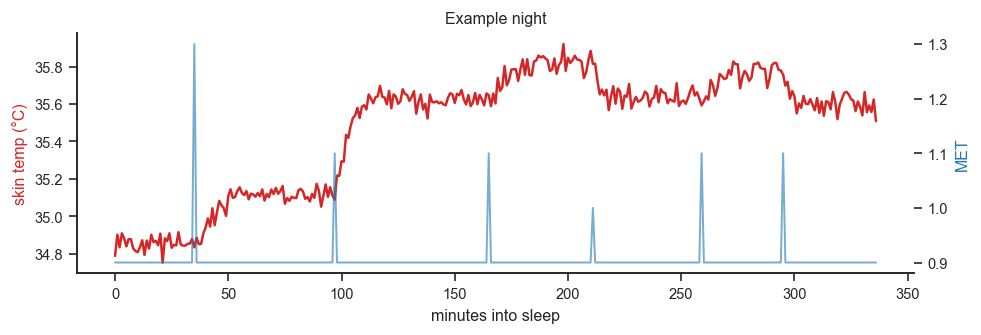

In [3]:
record = load_participant(f"{DATA}/P0000.parquet")
night = extract_sleep_windows(record, config=config)[0]

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(night["temp_skin"].values, color=viz.TEMP_COLOR, lw=1.5)
ax.set_ylabel("skin temp (°C)", color=viz.TEMP_COLOR)
ax2 = ax.twinx(); ax2.plot(night["met"].values, color=viz.MET_COLOR, alpha=0.6)
ax2.set_ylabel("MET", color=viz.MET_COLOR); ax.set_xlabel("minutes into sleep")
ax.set_title("Example night"); plt.show()

## 3. Select isolated activity perturbations
An **AP** is a MET event with no other activity in a 20-minute quiet zone on either side; we take the 20-minute temperature trajectory that follows it.

96 isolated-perturbation trajectories for P0000


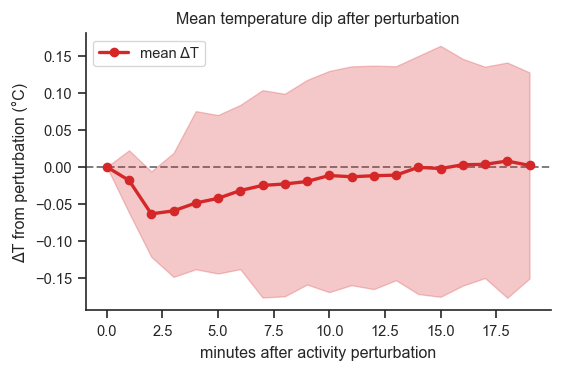

In [4]:
trajectories = extract_trajectories(extract_sleep_windows(record, config=config),
                                    "P0000", config=config)
cols = temp_columns(config)
print(f"{len(trajectories)} isolated-perturbation trajectories for P0000")

fig, ax = plt.subplots(figsize=(5, 3))
viz.plot_mean_trajectory(trajectories, cols, ax=ax)
ax.set_title("Mean temperature dip after perturbation"); plt.show()

## 4. Directional coupling: transfer entropy
MET carries more information about the *next* ΔT than ΔT does about the next MET — activity **leads** temperature change.

In [5]:
from skin_temp_perfusion.transfer_entropy import night_transfer_entropy
te = [night_transfer_entropy(w, config=config) for w in extract_sleep_windows(record, config=config)]
te = [t for t in te if t is not None]
if te:
    print(f"median TE(MET→ΔT) = {np.median([t.te_met_to_dtemp for t in te]):.4f} nats")
    print(f"median TE(ΔT→MET) = {np.median([t.te_dtemp_to_met for t in te]):.4f} nats")

median TE(MET→ΔT) = 0.0264 nats
median TE(ΔT→MET) = 0.0062 nats


## 5. Decompose one trajectory (Eqs. 4–6)
Stage 1 fits Newton recovery `k₁` on the smooth tail; stage 2 fits the activity residual `a·M·t^b·e^{−k₂t}` to what recovery cannot explain.

k1=0.340  a=0.428  b=0.000  k2=0.427  (recovery R²=0.84, residual R²=0.76)


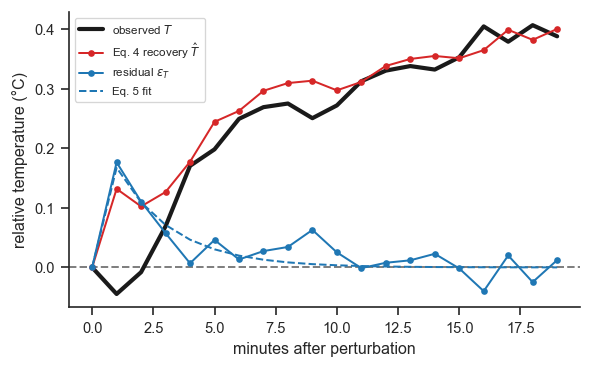

In [6]:
# Fit every trajectory (fit_trajectory returns None when the recovery gate
# fails) and show the best-fitting one as a clean example of the decomposition.
candidates = []
for _, r in trajectories.iterrows():
    y = r[cols].to_numpy(dtype=float)
    f = fit_trajectory(y, r["met0"])
    if f is not None:
        candidates.append((f.residual_r2, y, f))
_, y, fit = max(candidates, key=lambda c: c[0])
print(f"k1={fit.k1:.3f}  a={fit.a:.3f}  b={fit.b:.3f}  k2={fit.k2:.3f}"
      f"  (recovery R²={fit.recovery_r2:.2f}, residual R²={fit.residual_r2:.2f})")

fig, ax = plt.subplots(figsize=(5.5, 3.2))
viz.plot_decomposition(reconstruct(y, fit), ax=ax); plt.show()

## 6. Fit the whole cohort
Run the linear and mechanistic models across all participants.

median linear R² (1/2/3 var): {1: 0.384, 2: 0.389, 3: 0.579}


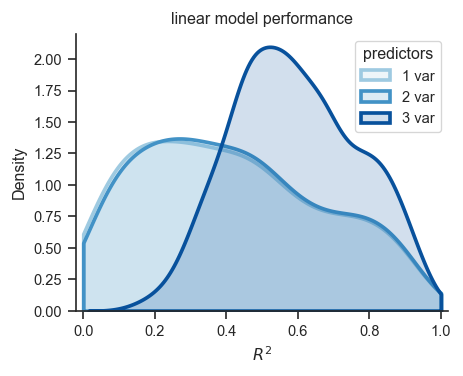

In [7]:
all_traj = pl.extract_all_trajectories(DATA, config=config, progress=False)
linear = pl.fit_all_linear_models(all_traj, config=config)
mech = pl.fit_all_mechanistic(all_traj, config=config, progress=False)
print("median linear R² (1/2/3 var):",
      {k: round(linear[f'r2_{k}var'].median(), 3) for k in (1, 2, 3)})

fig, ax = plt.subplots(figsize=(4, 3)); viz.plot_linear_model_r2(linear, ax=ax); plt.show()

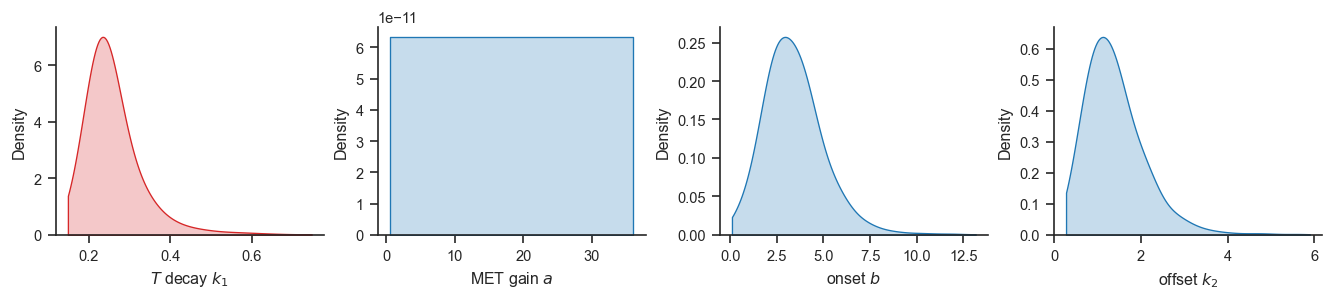

In [8]:
good = mech[mech["residual_r2"] >= config.residual_r2_min]
fig, axes = plt.subplots(1, 4, figsize=(11, 2.4), layout="constrained")
viz.plot_parameter_distributions(good, axes=axes); plt.show()

## 7. Cohort separation by dynamical biomarkers
Condition cohorts are compared to matched controls with Mann–Whitney U and Cohen's d. Positive *d* means controls are higher — the planted direction.

In [9]:
demographics = load_demographics(f"{DATA}/demographics.parquet")
effects, participants = pl.run_cohort_analysis(mech, demographics, config=config)
(effects.groupby(["condition", "param"]).cohen_d.median().unstack().round(2))

param,a,b,k1,k2
condition,,,,
AF,0.20,0.43,0.40,0.47
CAD,0.19,0.31,0.46,0.38
D,0.20,0.19,0.67,0.33
H,0.22,0.33,0.32,0.41
H+D,0.15,0.25,0.63,0.33


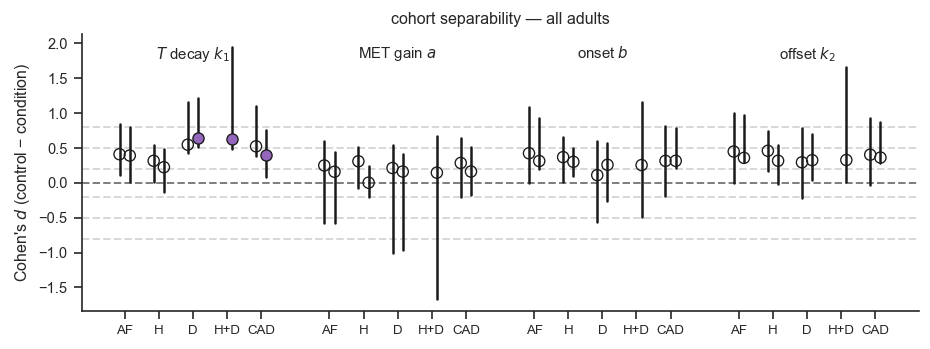

In [10]:
fig, ax = plt.subplots(figsize=(9, 3))
viz.plot_cohort_effect_sizes(effects, age_group="all", ax=ax); plt.show()

## Takeaway

The state-dependent mechanistic model summarizes each activity-perturbation
trajectory with four interpretable parameters, and those parameters separate
condition cohorts. On synthetic data the planted effects come back with the
correct sign and pattern — the estimators and code are working. For the real
findings and their physiological interpretation, see
[the paper](https://doi.org/10.1038/s41746-026-02633-2) and `docs/METHODS.md`.